# Car Price Prediction — EDA & Modeling

**Goal:** Predict the resale price of a used car from its listed attributes
(age, mileage, engine size, fuel type, transmission, etc.)

**Dataset:** [Vehicle Dataset from CarDekho](https://www.kaggle.com/datasets/nehalbirla/vehicle-dataset-from-cardekho)
— 8,128 real used-car listings scraped from CarDekho.com.

This notebook covers data loading, cleaning, feature engineering, and EDA,
followed by model training and evaluation.

In [1]:
import sys
sys.path.append("../src")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from clean_data import load_raw, clean

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

## 1. Loading the raw data

In [2]:
df_raw = load_raw("../data/raw/car_details_v3.csv")
print(df_raw.shape)
df_raw.head()

(8128, 13)


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


## 2. Initial inspection

Before cleaning, it's worth checking dtypes and missing values. Several
columns (`mileage`, `engine`, `max_power`, `torque`) are stored as text with
units baked in (e.g. `"23.4 kmpl"`), so they need parsing before they're usable.

In [3]:
df_raw.info()
print("\nMissing values:\n", df_raw.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8128 non-null   str    
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-null   str    
 5   seller_type    8128 non-null   str    
 6   transmission   8128 non-null   str    
 7   owner          8128 non-null   str    
 8   mileage        7907 non-null   str    
 9   engine         7907 non-null   str    
 10  max_power      7913 non-null   str    
 11  torque         7906 non-null   str    
 12  seats          7907 non-null   float64
dtypes: float64(1), int64(3), str(9)
memory usage: 825.6 KB

Missing values:
 name               0
year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              

## 3. Cleaning and feature engineering

The steps applied here (in `src/clean_data.py`):
- Units are stripped from `mileage`, `engine`, `max_power` and converted to float
- `brand` is extracted from the free-text `name` column
- `car_age` is engineered from `year` (more directly useful than a raw year value)
- Missing numeric values are filled with the column median (robust to skew)
- `km_driven` and `selling_price` are capped at the 99th percentile to tame extreme outliers
- `owner` is converted to an ordinal `owner_num` (fewer previous owners = simpler signal for the model)

In [4]:
df = clean(df_raw)
print(df.shape)
df.head()

(8128, 14)


,year,selling_price,km_driven,fuel,seller_type,transmission,owner,seats,mileage_kmpl,engine_cc,max_power_bhp,brand,car_age,owner_num
0,2014,450000.0,145500.0,Diesel,Individual,Manual,First Owner,5.0,23.40,1248.0,74.00,Maruti,12,1
1,2014,370000.0,120000.0,Diesel,Individual,Manual,Second Owner,5.0,21.14,1498.0,103.52,Skoda,12,2
2,2006,158000.0,140000.0,Petrol,Individual,Manual,Third Owner,5.0,17.70,1497.0,78.00,Honda,20,3
3,2010,225000.0,127000.0,Diesel,Individual,Manual,First Owner,5.0,23.00,1396.0,90.00,Hyundai,16,1
4,2007,130000.0,120000.0,Petrol,Individual,Manual,First Owner,5.0,16.10,1298.0,88.20,Maruti,19,1


In [5]:
df.isnull().sum()

year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
seats            0
mileage_kmpl     0
engine_cc        0
max_power_bhp    0
brand            0
car_age          0
owner_num        0
dtype: int64

## 4. Exploratory data analysis

### 4.1 Target distribution

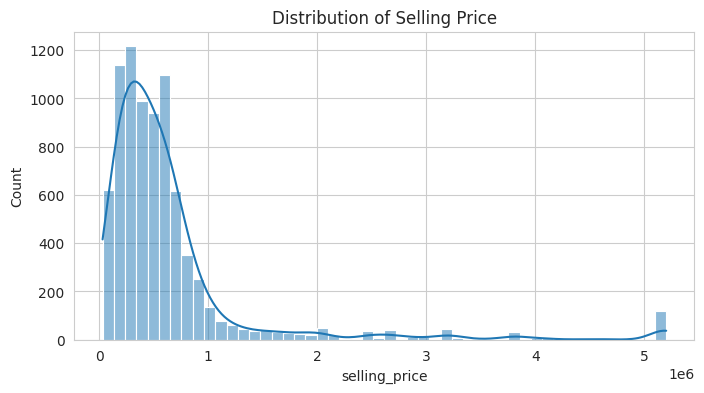

In [6]:
plt.figure(figsize=(8, 4))
sns.histplot(df["selling_price"], bins=50, kde=True)
plt.title("Distribution of Selling Price")
plt.show()

Selling price is right-skewed, as expected for a used-car market: most cars
cluster at lower price points with a long tail of premium vehicles.

### 4.2 Price vs. key numeric features

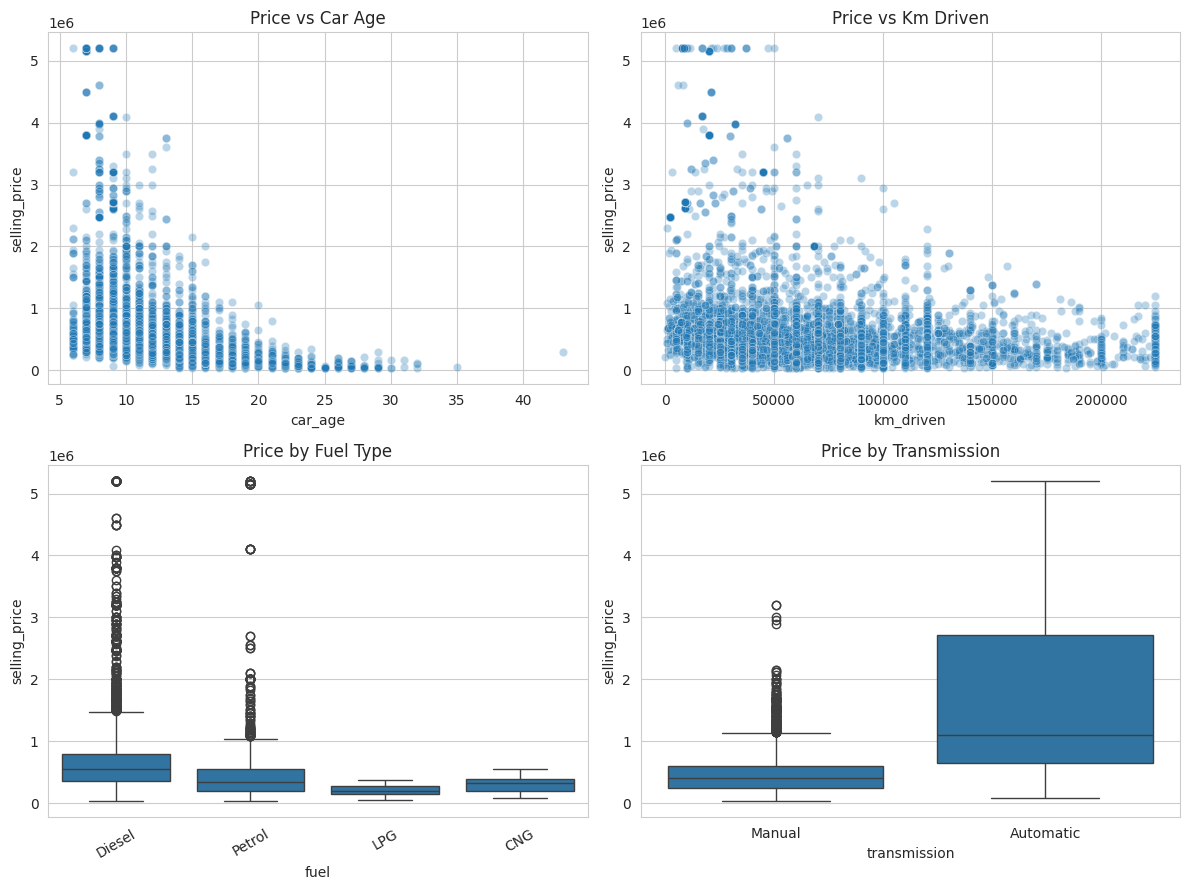

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

sns.scatterplot(data=df, x="car_age", y="selling_price", alpha=0.3, ax=axes[0, 0])
axes[0, 0].set_title("Price vs Car Age")

sns.scatterplot(data=df, x="km_driven", y="selling_price", alpha=0.3, ax=axes[0, 1])
axes[0, 1].set_title("Price vs Km Driven")

sns.boxplot(data=df, x="fuel", y="selling_price", ax=axes[1, 0])
axes[1, 0].set_title("Price by Fuel Type")
axes[1, 0].tick_params(axis="x", rotation=30)

sns.boxplot(data=df, x="transmission", y="selling_price", ax=axes[1, 1])
axes[1, 1].set_title("Price by Transmission")

plt.tight_layout()
plt.savefig("../visuals/eda_overview.png", dpi=120)
plt.show()

**Observations:**
- Price drops steeply with age for the first ~10 years, then flattens out.
- Price vs km driven shows a weaker, noisier negative trend.
- Diesel cars have a higher median price than petrol, LPG or CNG.
- Automatic transmission commands a clear price premium over manual.

### 4.3 Correlation heatmap (numeric features)

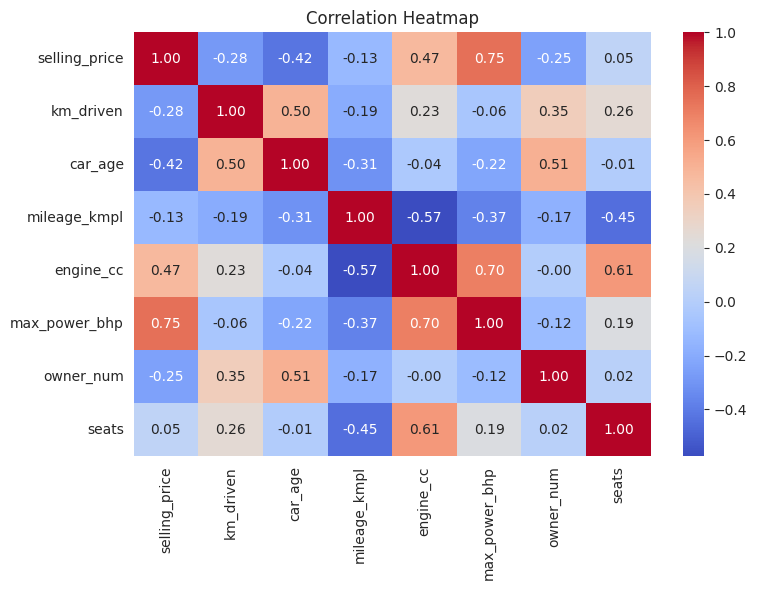

In [8]:
plt.figure(figsize=(8, 6))
numeric_cols = ["selling_price", "km_driven", "car_age", "mileage_kmpl",
                 "engine_cc", "max_power_bhp", "owner_num", "seats"]
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("../visuals/correlation_heatmap.png", dpi=120)
plt.show()

`max_power_bhp` and `engine_cc` are the strongest positive correlates of price;
`car_age` is the strongest negative correlate. This matches intuition and gives
a good sanity check before modeling.

## 5. Exporting the cleaned dataset

In [9]:
df.to_csv("../data/processed/car_clean.csv", index=False)
print("Cleaned dataset exported.")

Cleaned dataset exported.


---
## 6. Modeling

Three models of increasing complexity are compared:
- **Linear Regression** — simple baseline, assumes linear relationships
- **Random Forest** — an ensemble of decision trees, captures non-linear
  patterns (like price flattening out after ~10 years of age)
- **Gradient Boosting** — sequentially corrects errors, often very accurate
  but slower to train

Categorical features (`brand`, `fuel`, `seller_type`, `transmission`) are
one-hot encoded; numeric features are passed through unchanged. Both steps
live in one `sklearn` Pipeline so preprocessing and modeling can never get
out of sync between train and test data.

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

NUMERIC_FEATURES = ["car_age", "km_driven", "mileage_kmpl", "engine_cc",
                     "max_power_bhp", "seats", "owner_num"]
CATEGORICAL_FEATURES = ["brand", "fuel", "seller_type", "transmission"]
TARGET = "selling_price"

X = df[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (6502, 11), Test: (1626, 11)


### 6.1 Preprocessing and model pipeline

A reusable pipeline factory: one-hot encoding for categoricals, passthrough
for numerics, feeding into whichever regressor is passed in.

In [11]:
def build_pipeline(model):
    preprocessor = ColumnTransformer(transformers=[
        ("num", "passthrough", NUMERIC_FEATURES),
        ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_FEATURES),
    ])
    return Pipeline(steps=[("preprocess", preprocessor), ("model", model)])

candidates = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=200, max_depth=4, learning_rate=0.08, random_state=42),
}

### 6.2 Training and evaluating all three models

In [12]:
results = []
fitted = {}

for name, model in candidates.items():
    pipe = build_pipeline(model)
    pipe.fit(X_train, y_train)
    fitted[name] = pipe

    preds = pipe.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    results.append({"model": name, "rmse": rmse, "mae": mae, "r2": r2})

results_df = pd.DataFrame(results).sort_values("rmse").reset_index(drop=True)
results_df

,model,rmse,mae,r2
0,Random Forest,125184.405611,68223.479372,0.974987
1,Gradient Boosting,138495.682684,73689.087341,0.969384
2,Linear Regression,422637.711185,257199.117726,0.714893


### 6.3 Selecting the best model

Random Forest comes out ahead on RMSE, MAE, and R² — it's carried forward
as the final model.

In [13]:
best_name = results_df.iloc[0]["model"]
best_pipe = fitted[best_name]
print(f"Best model: {best_name}")

Best model: Random Forest


### 6.4 Feature importance

For the winning tree-based model, this shows which features drove its
predictions the most.

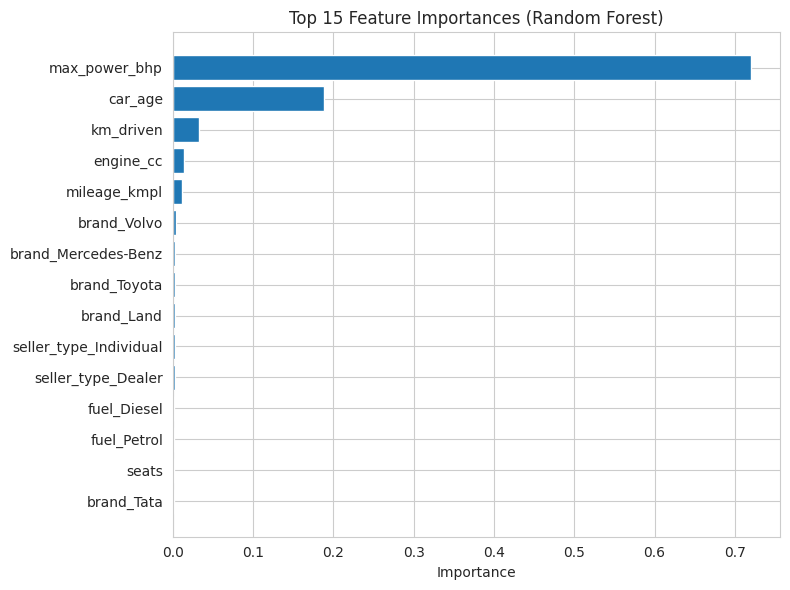

In [14]:
if best_name in ("Random Forest", "Gradient Boosting"):
    ohe = best_pipe.named_steps["preprocess"].named_transformers_["cat"]
    cat_names = ohe.get_feature_names_out(CATEGORICAL_FEATURES)
    all_names = NUMERIC_FEATURES + list(cat_names)

    importances = best_pipe.named_steps["model"].feature_importances_
    imp_df = pd.DataFrame({"feature": all_names, "importance": importances})
    imp_df = imp_df.sort_values("importance", ascending=False).head(15)

    plt.figure(figsize=(8, 6))
    plt.barh(imp_df["feature"][::-1], imp_df["importance"][::-1])
    plt.title(f"Top 15 Feature Importances ({best_name})")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.savefig("../visuals/feature_importance.png", dpi=120)
    plt.show()

`max_power_bhp` and `car_age` dominate — consistent with what the earlier
correlation heatmap already suggested. This agreement between EDA and the
trained model's feature importance is a good sanity check that the model
learned something real, not noise.

### 6.5 Predicted vs. actual price

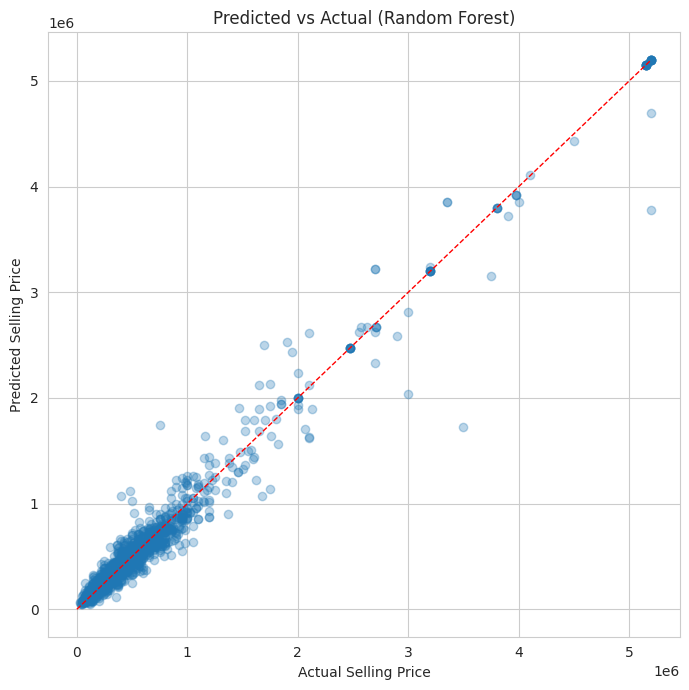

In [15]:
preds = best_pipe.predict(X_test)
plt.figure(figsize=(7, 7))
plt.scatter(y_test, preds, alpha=0.3)
lims = [0, max(y_test.max(), preds.max())]
plt.plot(lims, lims, "r--", linewidth=1)
plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title(f"Predicted vs Actual ({best_name})")
plt.tight_layout()
plt.savefig("../visuals/predicted_vs_actual.png", dpi=120)
plt.show()

Points cluster tightly along the diagonal across the full price range,
with no systematic over/under-prediction — a good sign the model
generalizes rather than just memorizing the training set.

### 6.6 Exporting the final model

In [16]:
import joblib
joblib.dump(best_pipe, "../models/best_model.pkl")
results_df.to_csv("../models/results.csv", index=False)
print("Best model and results table exported.")

Best model and results table exported.


## Conclusion

- Random Forest and Gradient Boosting both massively outperform the
  Linear Regression baseline, confirming the price/age relationship is
  non-linear (as the earlier EDA already hinted).
- `max_power_bhp` and `car_age` are by far the strongest predictors.
- The saved `models/best_model.pkl` can be loaded directly for inference
  without retraining: `joblib.load("models/best_model.pkl")`.